# Advanced EDA: Contribution, Cohort Drift, and Mix-Shift Decomposition

Three diagnostics that go beyond segment averages:

1. **Rate vs. contribution** — the segment with the highest churn *rate* is not necessarily the one contributing the most churned *users*; prioritization needs both views.
2. **Cohort quality drift** — whether newly acquired users are getting worse over time, independent of the aggregate picture.
3. **Mix-shift decomposition** — whether a change in the overall conversion rate comes from a shift in user structure (mix effect) or from within-group behavior change (performance effect).

## 1. Data Loading

Tables are loaded through the shared project loader and kept in a dict keyed by table name; the next section rolls them up to user grain.

In [1]:
# Environment setup. Data is auto-discovered by src/data_loader.py
# (./data in the repo, /content/data on Colab, or STREAMING_DATA_DIR).
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd

# Plotting and rich display degrade gracefully outside a notebook front end.
try:
    import matplotlib.pyplot as plt
    HAS_PLOT = True
except ModuleNotFoundError:
    HAS_PLOT = False

try:
    display
except NameError:
    def display(obj):
        print(obj)

pd.set_option("display.max_columns", 100)

from src.data_loader import load_dataframes

tables = load_dataframes()
for name, table in tables.items():
    print(f"{name}: {table.shape}")

users: (50000, 11)
listening_events: (1072063, 15)
subscription_events: (104498, 10)
ad_events: (310438, 10)
feature_table: (50000, 53)


## 2. User-Level Table Preparation

Builds a defensive one-row-per-user table from heterogeneous inputs: column names are normalized, event-grain tables are aggregated to user grain (flags/labels take `max`, counts take `sum`), everything is outer-joined on `user_id` with duplicate-column resolution, and the analysis variables (`active_level`, `signup_month`, retention label) are derived with fallbacks for missing columns.

In [2]:
def normalize_colname(col):
    return str(col).strip().lower().replace(" ", "_").replace("-", "_")


def aggregate_to_user_level(raw_df, table_name):
    raw_df = raw_df.copy()
    raw_df.columns = [normalize_colname(c) for c in raw_df.columns]

    if "user_id" not in raw_df.columns:
        return None

    if not raw_df["user_id"].duplicated().any():
        return raw_df

    numeric_cols = [c for c in raw_df.select_dtypes(include=np.number).columns if c != "user_id"]
    other_cols = [c for c in raw_df.columns if c not in numeric_cols + ["user_id"]]

    agg_dict = {}
    for col in numeric_cols:
        if col.endswith("_flag") or col.endswith("_label") or col.startswith("is_"):
            agg_dict[col] = "max"
        else:
            agg_dict[col] = "sum"

    for col in other_cols:
        agg_dict[col] = "first"

    out = raw_df.groupby("user_id", as_index=False).agg(agg_dict)
    print(f"{table_name}: aggregated to user level: {out.shape}")
    return out


user_tables = []
for name, table in tables.items():
    user_table = aggregate_to_user_level(table, name)
    if user_table is not None:
        user_tables.append(user_table)

if len(user_tables) == 0:
    raise ValueError("No table contains user_id.")

df = user_tables[0]
for right in user_tables[1:]:
    df = df.merge(right, on="user_id", how="outer", suffixes=("", "_dup"))
    # Resolve column collisions after each merge (left value wins, right
    # fills gaps); deferring this would create duplicate *_dup names when
    # three or more tables share a column.
    dup_cols = [c for c in df.columns if c.endswith("_dup")]
    for dup in dup_cols:
        base = dup.replace("_dup", "")
        if base in df.columns:
            df[base] = df[base].combine_first(df[dup])
        df = df.drop(columns=[dup])

alias_map = {
    "primary_device": "device",
    "device_type": "device",
    "acq_channel": "acquisition_channel",
    "channel": "acquisition_channel",
}

for old, new in alias_map.items():
    if old in df.columns and new not in df.columns:
        df[new] = df[old]

if "retention_label_30d" not in df.columns and "churn_label_14d" in df.columns:
    df["retention_label_30d"] = 1 - df["churn_label_14d"]

if "churn_label_14d" not in df.columns and "retention_label_30d" in df.columns:
    df["churn_label_14d"] = 1 - df["retention_label_30d"]

for col, default in {
    "device": "unknown",
    "acquisition_channel": "unknown",
    "subscription_type": "unknown",
    "paid_conversion_30d": 0,
    "churn_label_14d": 0,
    "retention_label_30d": 1,
}.items():
    if col not in df.columns:
        df[col] = default

if "active_days_30d" in df.columns:
    df["active_level"] = pd.cut(
        df["active_days_30d"],
        bins=[-0.1, 3, 12, 31],
        labels=["low", "medium", "high"]
    )
else:
    df["active_level"] = "unknown"

date_candidates = ["signup_date", "registration_date", "created_at", "signup_month"]
date_col = next((c for c in date_candidates if c in df.columns), None)
if date_col is not None:
    df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
    df["signup_month"] = df[date_col].dt.to_period("M").astype(str)
else:
    df["signup_month"] = "unknown"

print("Final user-level table:", df.shape)
display(df.head())

listening_events: aggregated to user level: (48187, 15)
subscription_events: aggregated to user level: (34640, 10)


ad_events: aggregated to user level: (31000, 10)


Final user-level table: (50000, 85)


,user_id,signup_date,country,language,region_tier,age_group,primary_device,acquisition_channel,student_eligible,marketing_opt_in,music_persona,track_duration_sec,play_duration_sec,completed_flag,skipped_flag,liked_flag,playlist_add_flag,search_used_flag,event_id,event_timestamp,session_id,device_type,content_type,genre,recommendation_source,price_usd,trial_length_days,subscription_event_id,event_type,plan_type,payment_method,campaign_id,source_touchpoint,ad_duration_sec,clicked_flag,revenue_usd,ad_event_id,ad_type,placement,snapshot_date,tenure_days,subscription_type,lifecycle_stage,active_days_7d,listen_events_7d,listen_minutes_7d,active_days_30d,listen_events_30d,listen_minutes_30d,sessions_30d,avg_play_duration_sec_30d,skip_rate_30d,completion_rate_30d,liked_songs_30d,playlist_adds_30d,search_events_30d,top_genre_30d,ad_impressions_30d,ad_clicks_30d,ad_click_rate_30d,ad_completions_30d,ad_completion_rate_30d,ad_impressions_per_active_day,ad_load_bucket,ad_revenue_30d,trial_exposed_30d,trial_started_30d,trial_used_before_snapshot,paid_started_30d,paid_conversion_30d,renewal_success_30d,payment_failed_30d,cancel_30d,trial_expired_30d,renewal_success_14d,subscription_revenue_30d,total_revenue_30d,active_level_30d,listening_level_30d,listen_events_14d,churn_label_14d,device,retention_label_30d,active_level,signup_month
0,U000001,2026-02-06,UK,en,Tier 1,35-44,mobile_android,organic_search,0,0,commute_listener,2602.0,2143.0,1.0,0.0,0.0,0.0,0.0,L000801048,2026-03-24 08:58:01,U000001_2026032403,desktop,song,jazz,editorial_playlist,21.98,0.0,S000050609,paid_started,individual_premium,carrier_billing,NO_CAMPAIGN,home_banner,168.0,1.0,0.0984,A000082323,audio,mid_roll,2026-04-01,54,free,casual_free,0.0,0.0,0.0000,1.0,1.0,1.9333,1.0,116.0,0.00,0.0,0.0,0.0,0.0,jazz,3.0,0.0,0.0,2.0,0.6667,3.0000,medium,0.0438,0,0,0,0,0,0,0,1,0,0,0.0,0.0438,low,very_low,2,0,mobile_android,1,low,2026-02
1,U000002,2026-03-07,ES,es,Tier 2,25-34,mobile_android,paid_social,0,0,playlist_builder,2109.0,1293.0,1.0,1.0,1.0,1.0,1.0,L000572025,2026-03-07 14:17:42,U000002_2026030702,mobile_ios,song,rock,user_playlist,0.00,7.0,S000087568,trial_exposed,trial,None,TRIAL_7D,playlist_prompt,153.0,0.0,0.0544,A000168313,display,homepage_banner,2026-04-01,25,free,engaged_free,3.0,3.0,7.1167,10.0,10.0,21.5500,10.0,129.3,0.20,0.3,1.0,1.0,2.0,rock,7.0,0.0,0.0,6.0,0.8571,0.7000,low,0.0544,1,0,0,0,0,0,0,0,0,0,0.0,0.0544,medium,low,0,1,mobile_android,0,medium,2026-03
2,U000003,2025-07-29,IN,en,Tier 2,18-24,mobile_android,referral,0,0,casual_listener,1638.0,1003.0,1.0,1.0,0.0,0.0,0.0,L000005080,2026-01-01 17:55:59,U000003_2026010103,mobile_android,song,news_podcast,home_recommendation,0.00,7.0,S000015581,trial_exposed,trial,None,TRIAL_7D,search_interruption,18.0,0.0,0.0166,A000072855,video,pre_roll_video,2026-04-01,246,free,casual_free,1.0,1.0,2.6500,3.0,3.0,6.5000,3.0,130.0,0.00,0.0,0.0,0.0,0.0,pop,1.0,0.0,0.0,0.0,0.0000,0.3333,low,0.0025,0,0,0,0,0,0,0,0,0,0,0.0,0.0025,low,very_low,0,1,mobile_android,0,low,2025-07
3,U000004,2025-11-14,FR,fr,Tier 1,35-44,mobile_android,referral,0,1,commute_listener,6525.0,4518.0,1.0,1.0,1.0,1.0,1.0,L000000799,2026-01-01 02:47:42,U000004_2026010104,mobile_android,song,pop,home_recommendation,0.00,37.0,S000022445,trial_exposed,trial,None,FAMILY_PLAN_PROMO,profile_page,150.0,0.0,0.1243,A000097443,audio,mid_roll,2026-04-01,138,free,casual_free,1.0,1.0,0.6000,4.0,4.0,11.3333,4.0,170.0,0.25,0.0,0.0,0.0,3.0,classical,2.0,0.0,0.0,1.0,0.5000,0.5000,low,0.0703,0,0,1,0,0,0,0,0,0,0,0.0,0.0703,medium,low,3,0,mobile_android,1,medium,2025-11
4,U000005,2025-05-21,US,en,Tier 1,25-34,mobile_ios,student_partner,1,0,casual_listener,3486.0,2768.0,1.0,1.0,1.0,0.0,0.0,L000719414,2026-03-18 10:46:38,U000005_2026031804,mobile_ios,song,jazz,home_recommendation,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026-04-01,315,free,casual_free,0.0,0.0,0.0000,1.0,1.0,2.7167,1.0,163.0,0.00,0.0,0.0,0.0,0.0,jazz,0.0,0.0,0.0,0.0,0.0000,0.0000,no_ads,0.0000,0,0,0,0,0,0,0,0,0,0,

## 3. Chart Helpers

Shared helpers keep chart output consistent and let the notebook run headless (plots are skipped when matplotlib is unavailable).

In [3]:
def show_bar(data, x, y, title, ylabel=None):
    if not HAS_PLOT:
        print(f"[Plot skipped] {title}")
        return

    plt.figure(figsize=(8, 4))
    plt.bar(data[x].astype(str), data[y])
    plt.title(title)
    plt.ylabel(ylabel or y)
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()


def safe_display(name, obj):
    print(f"\n--- {name} ---")
    display(obj)

## 4. Rate vs. Contribution

**Question.** Which segment has the highest churn rate, and which contributes the most churned users — and are they the same segment?

**Why.** Rate answers "who is riskiest per capita"; contribution answers "where the volume is". A small segment can churn at an extreme rate while barely moving the aggregate, and a large segment with a moderate rate can dominate it. Intervention priority needs both.

**Reading.** `metric_rate` ranks segments by internal risk; `contribution_share` ranks them by share of all churned users. Compare the two orderings.

**Action.** Where the rankings agree, that segment is the clear priority; where a large segment shows moderate rate but top contribution, structural fixes beat targeted campaigns.

**Limitation.** Contribution shares depend on how the segments are cut — a different segmentation redistributes them.


--- Rate vs Contribution ---


,active_level,users,metric_rate,metric_users,contribution_share
0,low,20952,0.696067,14584,0.613314
1,medium,20942,0.407745,8539,0.359098
2,high,8106,0.080928,656,0.027587


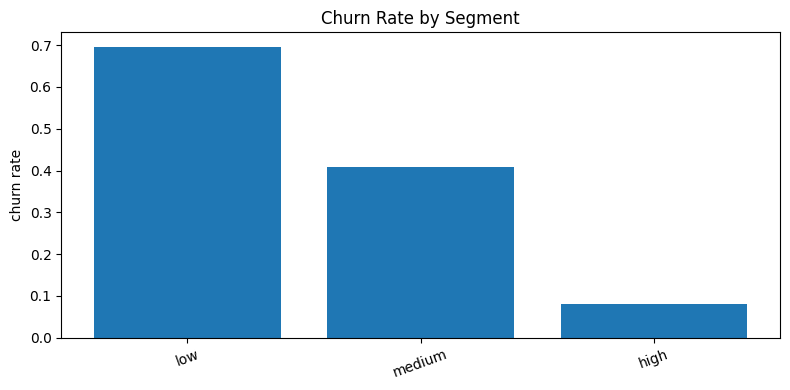

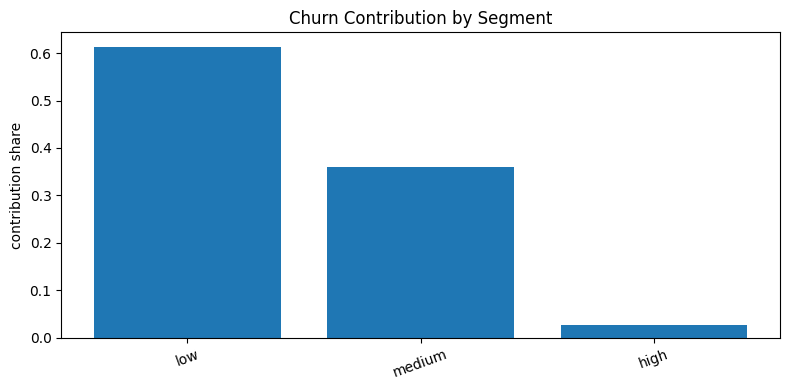

In [4]:
# Rate vs. contribution by segment: per-group churn rate and each
# group's share of all churned users.
segment_col = "active_level"
metric_col = "churn_label_14d"

temp = df[[segment_col, metric_col, "user_id"]].dropna(
    subset=[segment_col, metric_col]
)

contribution_summary = (
    temp.groupby(segment_col, observed=True)
        .agg(
            users=("user_id", "nunique"),
            metric_rate=(metric_col, "mean"),
            metric_users=(metric_col, "sum")
        )
        .reset_index()
)

total_metric_users = contribution_summary["metric_users"].sum()
contribution_summary["contribution_share"] = (
    contribution_summary["metric_users"] / total_metric_users
)

contribution_summary = contribution_summary.sort_values(
    "contribution_share",
    ascending=False
)

safe_display("Rate vs Contribution", contribution_summary)
show_bar(
    contribution_summary,
    segment_col,
    "metric_rate",
    "Churn Rate by Segment",
    "churn rate"
)
show_bar(
    contribution_summary,
    segment_col,
    "contribution_share",
    "Churn Contribution by Segment",
    "contribution share"
)

## 5. Cohort Quality Drift

**Question.** Is the quality of newly acquired users declining over time?

**Why.** Aggregate metrics can hide acquisition problems: a weakening recent cohort may reflect deteriorating channel quality, low-quality campaign traffic, or an onboarding regression.

**Reading.** Retention, conversion, and churn tracked by signup month. A sustained downward drift in recent cohorts flags an acquisition-quality problem rather than a product-wide one.

**Action.** If drift appears, split the affected cohorts by acquisition channel and device to locate the source.

**Limitation.** The newest cohorts have had less time to mature into their labels, which can bias their rates.


--- Cohort Quality ---


,signup_month,users,retention_rate,conversion_rate,churn_rate
0,2025-01,1370,0.529197,0.146715,0.470803
1,2025-02,2098,0.548618,0.149666,0.451382
2,2025-03,2571,0.546480,0.150525,0.453520
3,2025-04,3027,0.523951,0.162868,0.476049
4,2025-05,3281,0.521183,0.153307,0.478817
5,2025-06,3439,0.517592,0.154696,0.482408
6,2025-07,3886,0.531909,0.146423,0.468091
7,2025-08,4000,0.517000,0.157750,0.483000
8,2025-09,3960,0.531061,0.157323,0.468939
9,2025-10,4236,0.535647,0.162417,0.464353


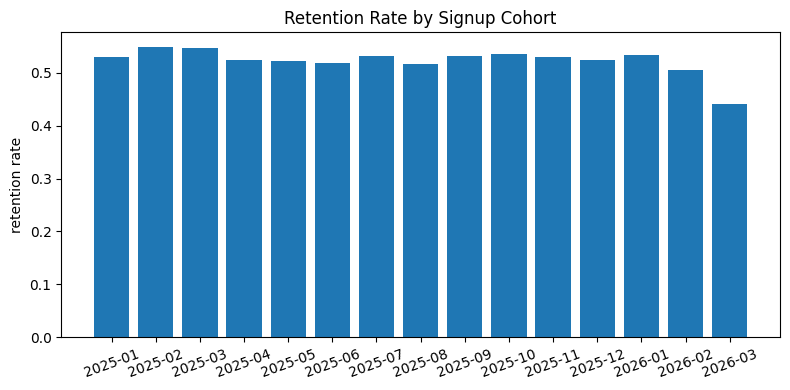

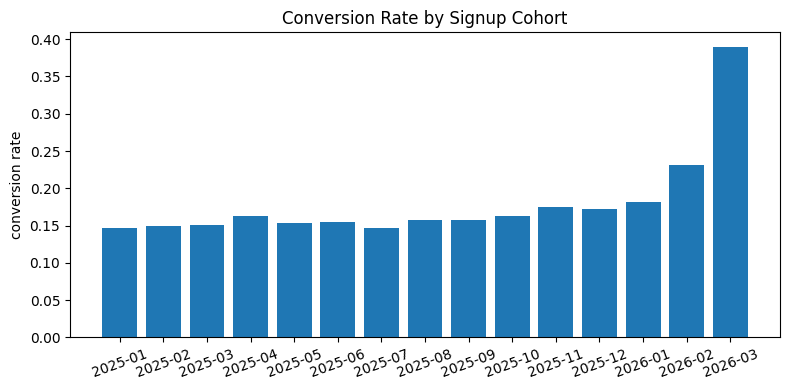

In [5]:
# Cohort quality by signup month: size, retention, conversion, churn.
cohort_df = df[
    df["signup_month"].notna() & (df["signup_month"] != "unknown")
].copy()

cohort_summary = (
    cohort_df.groupby("signup_month", observed=True)
        .agg(
            users=("user_id", "nunique"),
            retention_rate=("retention_label_30d", "mean"),
            conversion_rate=("paid_conversion_30d", "mean"),
            churn_rate=("churn_label_14d", "mean")
        )
        .reset_index()
        .sort_values("signup_month")
)

safe_display("Cohort Quality", cohort_summary)
show_bar(
    cohort_summary,
    "signup_month",
    "retention_rate",
    "Retention Rate by Signup Cohort",
    "retention rate"
)
show_bar(
    cohort_summary,
    "signup_month",
    "conversion_rate",
    "Conversion Rate by Signup Cohort",
    "conversion rate"
)

## 6. Mix-Shift Decomposition

**Question.** Is the change in overall paid conversion driven by a change in user structure (mix) or by within-group performance change?

**Why.** An overall rate can move without any group changing its behavior, purely because group weights shifted. Decomposing separates "our user base changed" from "our product performance changed" — two problems with entirely different owners.

**Method.** Users are split into `early` and `recent` periods by signup month. The overall rate in each period is Σ(mix × rate) over `active_level` groups. Holding early rates fixed at the recent mix isolates the **mix effect**; the remainder of the total change is the **performance effect**.

**Reading.** Compare `mix_effect` and `performance_effect` against `total_change` in the result table.

**Limitation.** The split depends on the grouping variable and the period boundary, and the interaction term is folded into the performance component.


--- Mix Detail ---


,period,active_level,users,rate,mix
0,early,low,8157,0.100895,0.414650
1,early,medium,8155,0.163213,0.414549
2,early,high,3360,0.251488,0.170801
3,recent,low,12795,0.133646,0.421887
4,recent,medium,12787,0.205287,0.421624
5,recent,high,4746,0.286979,0.156489



--- Mix Shift Result ---


,component,value
0,early_overall,0.152450
1,recent_overall,0.187846
2,total_change,0.035396
3,mix_effect,-0.001714
4,performance_effect,0.037110


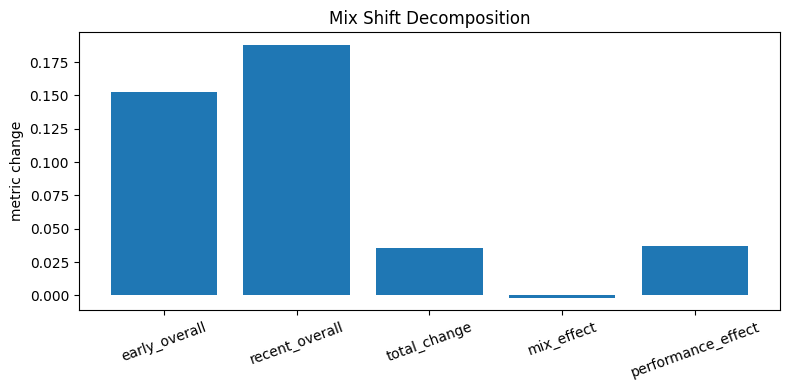

In [6]:
# Decompose overall conversion change into mix and performance effects.
group_col = "active_level"
metric_col = "paid_conversion_30d"

mix_df = df[
    df["signup_month"].notna() & (df["signup_month"] != "unknown")
].copy()

months = sorted(mix_df["signup_month"].unique())
split_idx = max(1, len(months) // 2)
early_months = set(months[:split_idx])

mix_df["period"] = np.where(
    mix_df["signup_month"].isin(early_months),
    "early",
    "recent"
)

grouped = (
    mix_df.dropna(subset=[group_col, metric_col])
        .groupby(["period", group_col], observed=True)
        .agg(
            users=("user_id", "nunique"),
            rate=(metric_col, "mean")
        )
        .reset_index()
)

grouped["mix"] = (
    grouped["users"] / grouped.groupby("period")["users"].transform("sum")
)

wide = grouped.pivot(
    index=group_col,
    columns="period",
    values=["mix", "rate"]
).fillna(0)

for top in ["mix", "rate"]:
    for period in ["early", "recent"]:
        if (top, period) not in wide.columns:
            wide[(top, period)] = 0

early_overall = (
    wide[("mix", "early")] * wide[("rate", "early")]
).sum()

recent_overall = (
    wide[("mix", "recent")] * wide[("rate", "recent")]
).sum()

mix_only = (
    wide[("mix", "recent")] * wide[("rate", "early")]
).sum()

total_change = recent_overall - early_overall
mix_effect = mix_only - early_overall
performance_effect = recent_overall - mix_only

mix_result = pd.DataFrame({
    "component": [
        "early_overall",
        "recent_overall",
        "total_change",
        "mix_effect",
        "performance_effect"
    ],
    "value": [
        early_overall,
        recent_overall,
        total_change,
        mix_effect,
        performance_effect
    ]
})

safe_display("Mix Detail", grouped)
safe_display("Mix Shift Result", mix_result)
show_bar(
    mix_result,
    "component",
    "value",
    "Mix Shift Decomposition",
    "metric change"
)

## 7. Key Findings

1. **Rate and contribution point at the same segment — the priority is unambiguous.** Low-activity users have both the highest churn rate (69.6%) and the largest contribution (61.3% of all churned users; 14,584 of 23,779). High-activity users churn at 8.1% and contribute just 2.8% — a monitoring concern, not an intervention target.
2. **No cohort-quality drift.** Retention holds at roughly 52–55% across sixteen signup months with no downward trend, while conversion drifts *upward* from ~14.7% (early 2025) to ~17–18% (recent cohorts). The newest cohort's outlier rates (44.0% retention, 39.0% conversion in 2026-03) reflect short label maturity, not real deterioration.
3. **The conversion improvement is performance, not mix.** The +3.5pp overall conversion change between early and recent cohorts decomposes into −0.2pp mix effect and +3.7pp performance effect: user structure is essentially stable, and every activity tier converts better (low 10.1% → 13.4%, medium 16.3% → 20.5%, high 25.1% → 28.7%). Whatever changed, it improved conversion within groups rather than reshaping the user base.

Caveats: the decomposition depends on the grouping variable and the early/recent boundary (the interaction term is folded into the performance component), and immature labels bias the newest cohorts.